# PINN example notebook: Logistic Regression

This is an example notebook to learn the basics of Pysics Informed Neural Networks (PINNs) with a very simple example:|
Logistic Regression

The differential equation for logistic regression can be solved analytically. \
Using a neural network to learn this solution to the problem aims to explain the concept and application of a PINN to differential equations in general.

In [24]:
import torch 
import torchopt
from torch import nn

import matplotlib.pyplot as plt

import numpy as np

from functorch import make_functional
from torch.func import grad, vmap

import torch.nn as nn

In [30]:
# NNApproximator will be the neural network consisting of an input layer, 
# an output layer, hidden layers in between and tanh as activation function
class NNApproximator(nn.Module):
    def __init__(
        self,
        num_inputs: int = 1,
        num_outputs: int = 1,
        num_hidden: int = 2,
        dim_hidden: int = 2,
        act: nn.Module = nn.Tanh(),
    ) -> None:
        """Simple neural network with linear layers and non-linear activation function
        This class is used as universal function approximator for the solution of
        partial differential equations using PINNs
        Args:
            num_inputs (int, optional): The number of input dimensions
            num_outputs (int, optional): The number of outputs of the model, in general is 1
            num_hidden (int, optional): The number of hidden layeim_hidden rs in the model
            dim_hidden (int, optional): The number of neurons for each hidden layer
            act (nn.Module, optional): The type of non-linear activation function to be used
        """
        super().__init__()

        # creates linear input and output layers 
        
        # input layer has num_input inputs neurons and dim_hidden outputs
        self.layer_in = nn.Linear(num_inputs, dim_hidden)
        # output layer has dim_hidden inputs neurons and num_outputs outputs
        self.layer_out = nn.Linear(dim_hidden, num_outputs)

        num_middle = num_hidden - 1
        self.middle_layers = nn.ModuleList(
            [nn.Linear(dim_hidden, dim_hidden) for _ in range(num_middle)]
        )
        self.act = act

        self.num_inputs = num_inputs
        self.num_outputs = num_outputs

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.act(self.layer_in(x))
        for layer in self.middle_layers:
            out = self.act(layer(out))
        return self.layer_out(out)


In [31]:
# create the PINN model and make it functional using functorch utilities
model = NNApproximator()
fmodel, params = make_functional(model)

/tikhome/lmeyer/miniconda3/envs/work/lib/python3.10/site-packages/torch/_functorch/deprecated.py:97: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.make_functional is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.func.functional_call instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('make_functional', 'torch.func.functional_call')


In [32]:
def f(x: torch.Tensor, params: torch.Tensor) -> torch.Tensor:
    """
    Function for vmapping the model over multiple inputs. 

    Vmapping over multiple inputs results in a dimensionless tensor. 
    Therefore, in order for the model to be able to process the input,
    the input must be unsqueezed to add a batch dimension.
    For the vmapped output to be a tensor of the same shape as the input, the
    output must be squeezed again.

    Moreover, in order to compute higher order derivatives, x is passed as the
    first argument and the parameters as the second argument. 
    This is because the `grad` function of PyTorch takes the first argument as
    default for computing the gradient.

    Parameters:
    -----------
        x (torch.Tensor): The input tensor
        params (torch.Tensor): The parameters of the model
    Returns:
    --------
        res (torch.Tensor): The output of the model
    """
    # only a single element is supported thus unsqueeze must be applied
    # for batching multiple inputs, `vmap` must be used as below
    x_ = x.unsqueeze(0)
    res = fmodel(params, x_).squeeze(0)
    return res

# use `vmap` primitive to allow efficient batching of the input
f_vmap = vmap(f, in_dims=(0, None))

# return function for computing higher order gradients with respect
# to input by simply composing `grad` calls and use again `vmap` for
# efficient batching of the input

dfdx = vmap(grad(f), in_dims=(0, None))
d2fdx2 = vmap(grad(grad(f)), in_dims=(0, None))

In [33]:
R = 1.0  # rate of maximum population growth parameterizing the equation
X_BOUNDARY = 0.0  # boundary condition coordinate
F_BOUNDARY = 0.5  # boundary condition value


def loss_fn(params: torch.Tensor, x: torch.Tensor) -> torch.Tensor:

    # interior loss
    f_value = f_vmap(x, params)

    interior = dfdx(x, params) - R * f_value * (1 - f_value)

    # boundary loss
    x0 = X_BOUNDARY
    f0 = F_BOUNDARY
    x_boundary = torch.tensor([x0])
    f_boundary = torch.tensor([f0])
    # calculates difference between the the functional value at the boundary and the aimed value
    boundary = f(x_boundary, params) - f_boundary

    # calculates the mean squared error using the nn.MSELoss function
    loss = nn.MSELoss()
    loss_value = loss(interior, torch.zeros_like(interior)) + loss(
        boundary, torch.zeros_like(boundary)
    )

    return loss_value

Iteration 0 with loss 0.6046196222305298
Iteration 1 with loss 0.26006096601486206
Iteration 2 with loss 0.10843157768249512
Iteration 3 with loss 0.06738823652267456
Iteration 4 with loss 0.05695177614688873
Iteration 5 with loss 0.07366298884153366
Iteration 6 with loss 0.09968777000904083
Iteration 7 with loss 0.09155544638633728
Iteration 8 with loss 0.05975042283535004
Iteration 9 with loss 0.03854101151227951
Iteration 10 with loss 0.025485215708613396
Iteration 11 with loss 0.028610656037926674
Iteration 12 with loss 0.033741988241672516
Iteration 13 with loss 0.0367947593331337
Iteration 14 with loss 0.03928808495402336
Iteration 15 with loss 0.03462671488523483
Iteration 16 with loss 0.034826166927814484
Iteration 17 with loss 0.022406745702028275
Iteration 18 with loss 0.018568439409136772
Iteration 19 with loss 0.010839523747563362
Iteration 20 with loss 0.012057391926646233
Iteration 21 with loss 0.017587479203939438
Iteration 22 with loss 0.019013255834579468
Iteration 23 

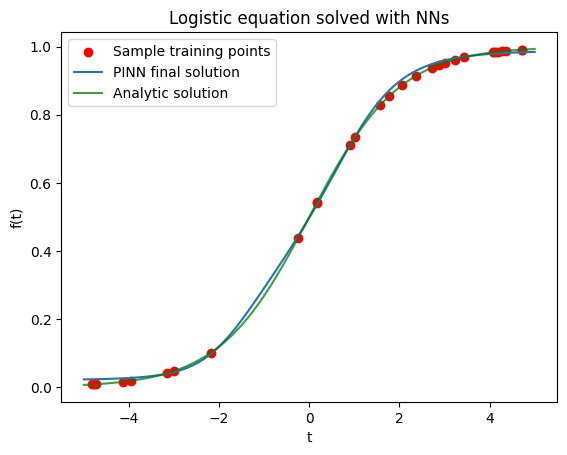

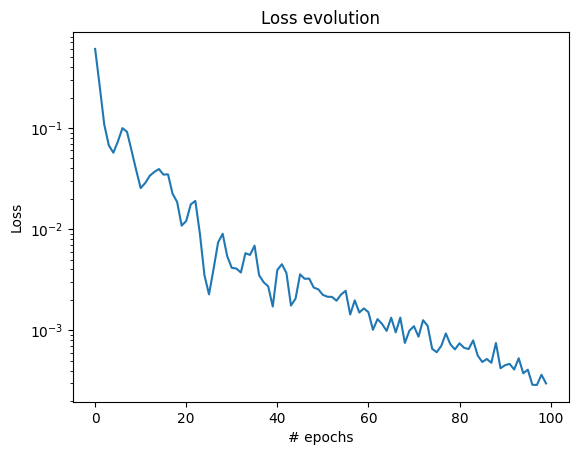

In [34]:
# choose the configuration
batch_size = 30  # number of colocation points sampled in the domain
num_iter = 100  # maximum number of iterations
learning_rate = 1e-1  # learning rate
domain = (-5.0, 5.0)  # logistic equation domain

# choose optimizer with functional API using functorch
optimizer = torchopt.FuncOptimizer(torchopt.adam(lr=learning_rate))

#list that keeps track of the loss evolution
loss_evolution = []

# train the model
for i in range(num_iter):

    # sample colocations points in the domain randomly at each epoch
    x = torch.FloatTensor(batch_size).uniform_(domain[0], domain[1])

    # update the parameters using the functional API
    loss = loss_fn(params, x)
    params = optimizer.step(loss, params)

    print(f"Iteration {i} with loss {float(loss)}")
    
    #appends the loss from every iteration to the loss_evolution list
    loss_evolution.append(float(loss))

# plot solution on the given domain

# creates list, with entries between 0 and 1 in 100 steps. 
# reshape brings it in form of a vektor 
# -1 => the vector has as many rows as entries
# 1 => the vector has one column
x_eval = torch.linspace(domain[0], domain[1], steps=100).reshape(-1, 1)
# evaluates the function values to the given x values
f_eval = f(x_eval, params)
# creates a analytical solution for comparison purposes
analytical_sol_fn = lambda x: 1.0 / (1.0 + (1.0/F_BOUNDARY - 1.0) * np.exp(-R * x))
# creates a numpy array from x_eval and detaches it from x_eval
x_eval_np = x_eval.detach().numpy()
# creates an numpy array with the x values of the sample points
x_sample_np = torch.FloatTensor(batch_size).uniform_(domain[0], domain[1]).detach().numpy()

#creates Figures and axes

fig, ax = plt.subplots()

# creates a scatter plot of the Sample training points
ax.scatter(x_sample_np, analytical_sol_fn(x_sample_np), color="red", label="Sample training points")
# ads the PINN solution and the analytical solution to the plot
ax.plot(x_eval_np, f_eval.detach().numpy(), label="PINN final solution")
ax.plot(
    x_eval_np,
    analytical_sol_fn(x_eval_np),
    label=f"Analytic solution",
    color="green",
    alpha=0.75,
)
ax.set(title="Logistic equation solved with NNs", xlabel="t", ylabel="f(t)")
ax.legend()

fig, ax = plt.subplots()
ax.semilogy(loss_evolution)
ax.set(title="Loss evolution", xlabel="# epochs", ylabel="Loss")


plt.show()

# Similar Setup with Pytorch 2.0

In [149]:
# create the PINN model using the new pytorch API
model = NNApproximator()

params = dict(model.named_parameters())
fmodel = torch.func.functionalize(model)
x = torch.rand(3, 1)
fmodel(x)

tensor([[0.5099],
        [0.5053],
        [0.5047]], grad_fn=<AddmmBackward0>)